In [2]:
import json
from io import StringIO
from pathlib import Path
import pandas as pd


def load_highest_result_log(path="../../data/round_1/results_data/176964.log"):
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        raw = json.load(f)

    print(raw.keys())  # helps confirm field names

    # IMC logs often store the activity table under "activitiesLog"
    # but sometimes the structure can differ, so we check safely.
    activities_text = raw.get("activitiesLog")

    if activities_text is None:
        raise KeyError(f"No 'activitiesLog' key found. Available keys: {list(raw.keys())}")

    activities = pd.read_csv(
        StringIO(activities_text),
        sep=";",
        na_values=["", "null", "None"],
    )

    trades = pd.DataFrame(raw.get("tradeHistory", []))
    sandbox = pd.DataFrame(raw.get("sandboxLogs", []))

    return {
        "submission_id": raw.get("submissionId"),
        "activities": activities,
        "trades": trades,
        "sandbox": sandbox,
        "raw": raw,
    }


parsed = load_highest_result_log()
activities_df = parsed["activities"]
trades_df = parsed["trades"]
sandbox_df = parsed["sandbox"]

dict_keys(['submissionId', 'activitiesLog', 'logs', 'tradeHistory'])


In [3]:
root_prices = activities_df[activities_df["product"] == "INTARIAN_PEPPER_ROOT"]
root_trades = trades_df[trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"]

ash_prices = activities_df[activities_df["product"] == "ASH_COATED_OSMIUM"]
ash_trades = trades_df[trades_df["symbol"] == "ASH_COATED_OSMIUM"]

In [4]:
ash_buys = ash_trades[ash_trades["buyer"] == "SUBMISSION"]
ash_sells = ash_trades[ash_trades["seller"] == "SUBMISSION"]

root_buys = root_trades[root_trades["buyer"] == "SUBMISSION"]
root_sells = root_trades[root_trades["seller"] == "SUBMISSION"]

<function matplotlib.pyplot.show(close=None, block=None)>

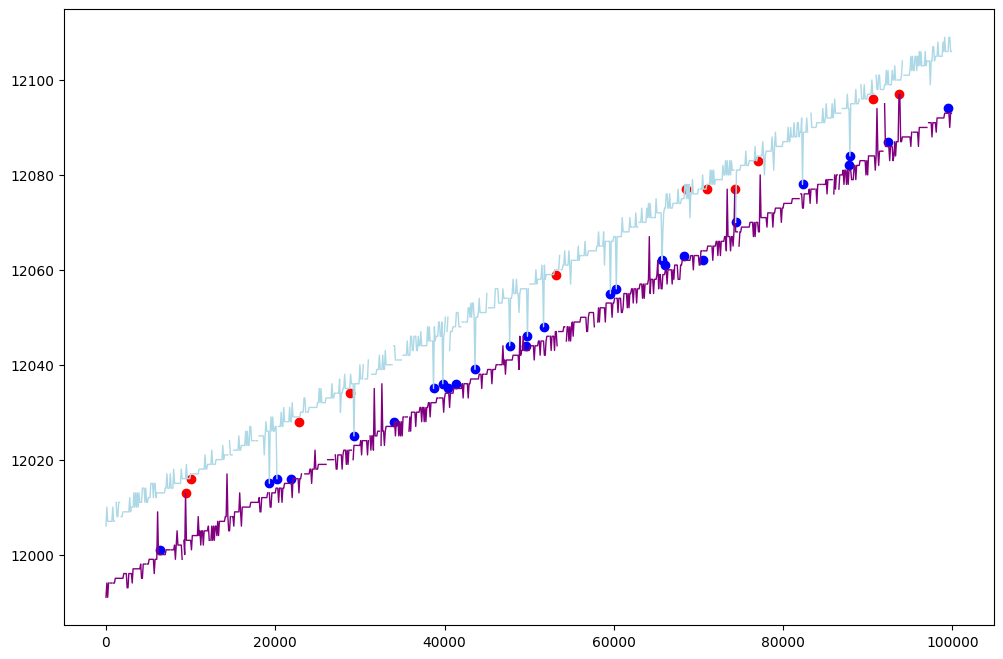

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(root_prices["timestamp"], root_prices["bid_price_1"], lw=1, color="purple")
#plt.plot(ash_prices["timestamp"], ash_prices["bid_price_2"], lw=1, color="darkblue")
#plt.plot(ash_prices["timestamp"], ash_prices["bid_price_3"], lw=1, color="red")
plt.plot(root_prices["timestamp"], root_prices["ask_price_1"], lw=1, color="lightblue")
#plt.plot(ash_prices["timestamp"], ash_prices["ask_price_2"], lw=1, color="darkblue")
#plt.plot(ash_prices["timestamp"], ash_prices["ask_price_3"], lw=1, color="red")
plt.scatter(root_buys["timestamp"], root_buys["price"], color="blue")
plt.scatter(root_sells["timestamp"], root_sells["price"], color="red")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

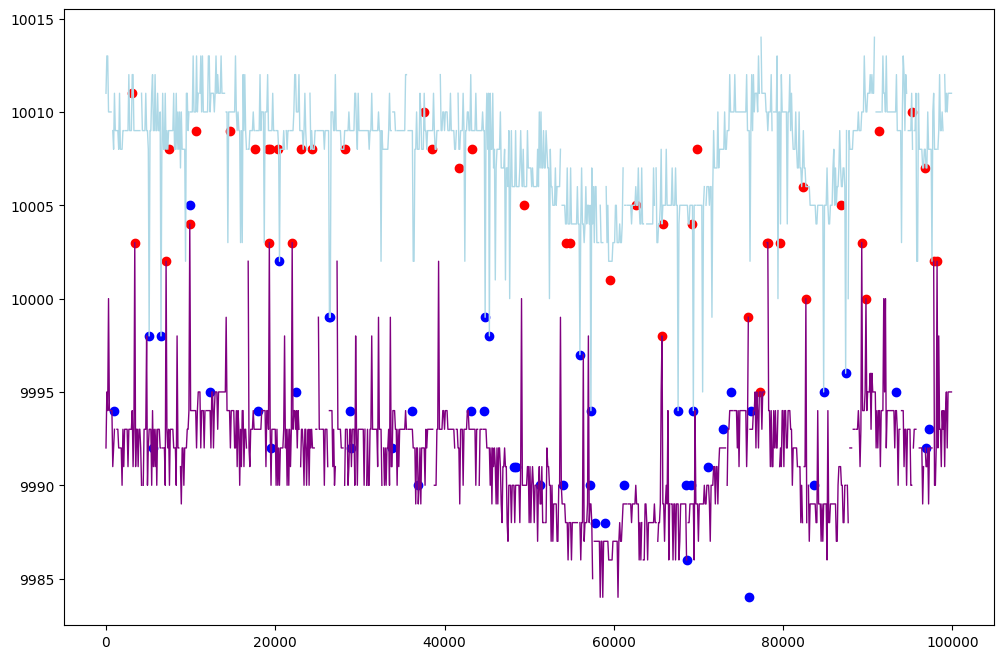

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(ash_prices["timestamp"], ash_prices["bid_price_1"], lw=1, color="purple")
#plt.plot(ash_prices["timestamp"], ash_prices["bid_price_2"], lw=1, color="darkblue")
#plt.plot(ash_prices["timestamp"], ash_prices["bid_price_3"], lw=1, color="red")
plt.plot(ash_prices["timestamp"], ash_prices["ask_price_1"], lw=1, color="lightblue")
#plt.plot(ash_prices["timestamp"], ash_prices["ask_price_2"], lw=1, color="darkblue")
#plt.plot(ash_prices["timestamp"], ash_prices["ask_price_3"], lw=1, color="red")
plt.scatter(ash_buys["timestamp"], ash_buys["price"], color="blue")
plt.scatter(ash_sells["timestamp"], ash_sells["price"], color="red")
plt.show